Using Colab cache for faster access to the 'cattle-breeds-dataset' dataset.
Dataset downloaded to: /kaggle/input/cattle-breeds-dataset
Using data from: /kaggle/input/cattle-breeds-dataset/Cattle Breeds
Class Names: ['Ayrshire cattle', 'Brown Swiss cattle', 'Holstein Friesian cattle', 'Jersey cattle', 'Red Dane cattle']
Epoch 1/25 | Train Acc=53.58% | Val Acc=73.11%
Epoch 2/25 | Train Acc=72.54% | Val Acc=75.63%
Epoch 3/25 | Train Acc=76.17% | Val Acc=82.35%
Epoch 4/25 | Train Acc=81.97% | Val Acc=87.39%
Epoch 5/25 | Train Acc=85.49% | Val Acc=90.76%
Epoch 6/25 | Train Acc=86.11% | Val Acc=93.28%
Epoch 7/25 | Train Acc=87.46% | Val Acc=93.28%
Epoch 8/25 | Train Acc=89.33% | Val Acc=93.28%
Epoch 9/25 | Train Acc=92.02% | Val Acc=96.64%
Epoch 10/25 | Train Acc=91.09% | Val Acc=95.80%
Epoch 11/25 | Train Acc=92.33% | Val Acc=94.12%
Epoch 12/25 | Train Acc=91.71% | Val Acc=94.96%
Epoch 13/25 | Train Acc=92.95% | Val Acc=96.64%
Epoch 14/25 | Train Acc=92.44% | Val Acc=93.28%

⏹ Early stoppin

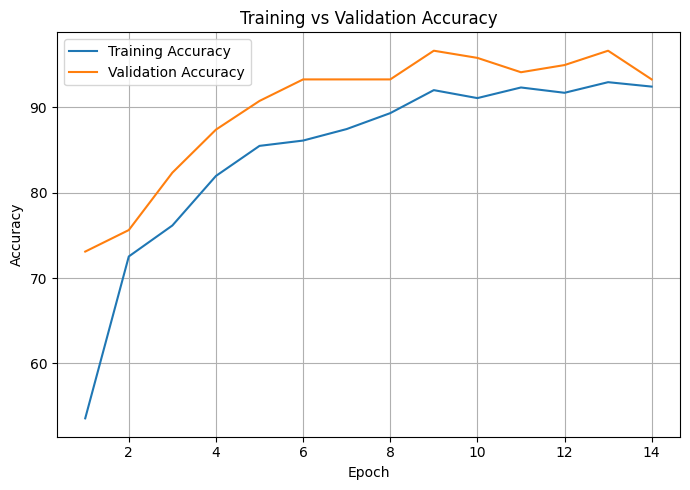

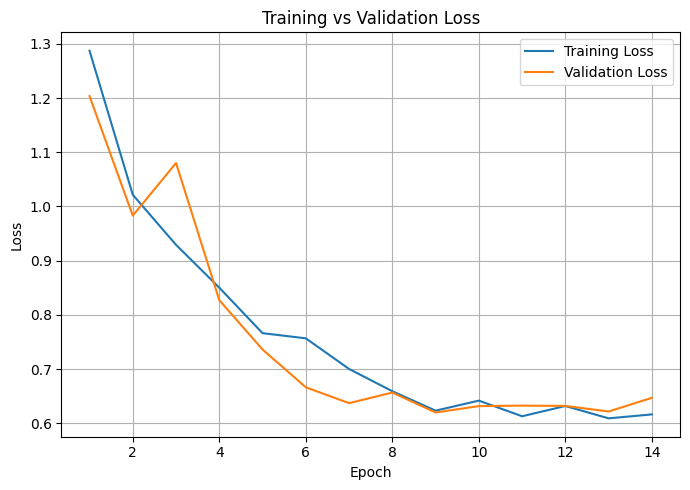


TEST ACCURACY & REPORT
                          precision    recall  f1-score   support

         Ayrshire cattle       0.92      0.88      0.90        26
      Brown Swiss cattle       0.96      0.88      0.92        25
Holstein Friesian cattle       0.89      0.92      0.91        26
           Jersey cattle       0.82      0.88      0.85        26
         Red Dane cattle       0.76      0.76      0.76        21

                accuracy                           0.87       124
               macro avg       0.87      0.87      0.87       124
            weighted avg       0.87      0.87      0.87       124



In [ ]:
# ======================
# DOWNLOAD DATASET USING KAGGLEHUB
# ======================
import os
import kagglehub

path = kagglehub.dataset_download("anandkumarsahu09/cattle-breeds-dataset")
print("Dataset downloaded to:", path)

DATA_DIR = os.path.join(path, "Cattle Breeds")
print("Using data from:", DATA_DIR)


# ======================
# IMPORTS & SETUP
# ======================
import time, random
import numpy as np
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ======================
# TRANSFORMS
# ======================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


# ======================
# LOAD DATASET
# ======================
base = datasets.ImageFolder(DATA_DIR, transform=test_transform)
class_names = base.classes
num_classes = len(class_names)
print("Class Names:", class_names)


# ======================
# STRATIFIED SPLIT
# ======================
def stratified_split(dataset, train_ratio=0.8, val_ratio=0.1):
    rng = np.random.default_rng(42)
    idxs = defaultdict(list)

    for i, (_, lb) in enumerate(dataset.samples):
        idxs[lb].append(i)

    train, val, test = [], [], []

    for lb, arr in idxs.items():
        arr = np.array(arr)
        rng.shuffle(arr)
        n = len(arr)
        t = int(train_ratio*n)
        v = int(val_ratio*n)

        train.extend(arr[:t])
        val.extend(arr[t:t+v])
        test.extend(arr[t+v:])

    return train, val, test


train_idx, val_idx, test_idx = stratified_split(base)


# ======================
# SUBSET DATASET
# ======================
class SubsetWithTransform(Dataset):
    def __init__(self, base, idxs, tfm):
        self.base = base
        self.idxs = idxs
        self.samples = base.samples
        self.transform = tfm

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, i):
        real = self.idxs[i]
        path, label = self.samples[real]
        img = self.base.loader(path)
        return self.transform(img), label


train_loader = DataLoader(
    SubsetWithTransform(base, train_idx, train_transform),
    batch_size=16, shuffle=True
)

val_loader = DataLoader(
    SubsetWithTransform(base, val_idx, test_transform),
    batch_size=16
)

test_loader = DataLoader(
    SubsetWithTransform(base, test_idx, test_transform),
    batch_size=16
)


# ======================
# MODEL
# ======================
class MobileNetEnhanced(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        m = models.mobilenet_v2(
            weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
        )

        for p in m.features[:-4].parameters():
            p.requires_grad = False

        self.features = m.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.pool(self.features(x)).flatten(1)
        return self.classifier(x)


model = MobileNetEnhanced(num_classes).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)


# ======================
# EARLY STOPPING
# ======================
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = float('inf')
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


early_stopping = EarlyStopping(patience=5)


# ======================
# METRIC STORAGE
# ======================
train_acc_list = []
val_acc_list = []
train_loss_epoch = []
val_loss_epoch = []


# ======================
# TRAIN LOOP (WITH EARLY STOPPING)
# ======================
def train(model, epochs=25):
    for ep in range(epochs):
        model.train()
        correct, total = 0, 0
        epoch_train_loss = 0.0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        train_acc_list.append(train_acc)
        train_loss_epoch.append(epoch_train_loss / len(train_loader))

        model.eval()
        v_correct, v_total = 0, 0
        epoch_val_loss = 0.0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                epoch_val_loss += loss.item()
                preds = outputs.argmax(1)
                v_correct += (preds == labels).sum().item()
                v_total += labels.size(0)

        val_acc = 100 * v_correct / v_total
        val_acc_list.append(val_acc)
        val_loss_epoch.append(epoch_val_loss / len(val_loader))

        scheduler.step()

        print(
            f"Epoch {ep+1}/{epochs} | "
            f"Train Acc={train_acc:.2f}% | "
            f"Val Acc={val_acc:.2f}%"
        )

        # ---------- EARLY STOPPING ----------
        early_stopping(val_loss_epoch[-1])
        if early_stopping.stop:
            print(f"\n⏹ Early stopping triggered at epoch {ep+1}")
            break

    return model


model = train(model)


# ======================
# ACCURACY GRAPH
# ======================
epochs = range(1, len(train_acc_list) + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, train_acc_list, label="Training Accuracy")
plt.plot(epochs, val_acc_list, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ======================
# LOSS GRAPH
# ======================
plt.figure(figsize=(7,5))
plt.plot(epochs, train_loss_epoch, label="Training Loss")
plt.plot(epochs, val_loss_epoch, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ======================
# TEST RESULTS
# ======================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nTEST ACCURACY & REPORT")
print(classification_report(all_labels, all_preds, target_names=class_names))


Saving images.webp to images.webp
Image: images.webp

Predicted Breed: Brown Swiss cattle
Confidence: 0.9946436882019043


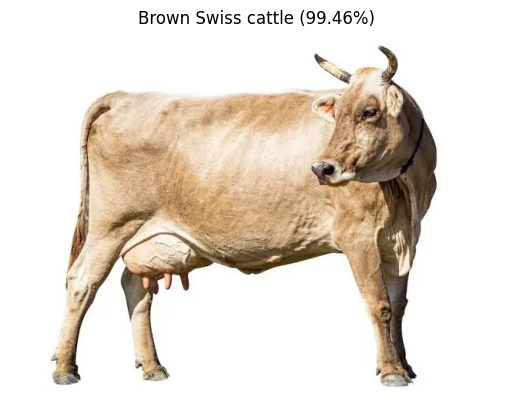

In [ ]:
# ============================
# IMAGE PREDICTION (UPLOAD FILE)
# ============================

from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt   # <-- ADD THIS

uploaded = files.upload()  # Choose an image

for filename in uploaded.keys():
    img_path = filename
    print("Image:", img_path)

    # Load the image
    img = Image.open(img_path).convert("RGB")

    # Apply same preprocess as test dataset
    tfm = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485,0.456,0.406],
            [0.229,0.224,0.225],
        ),
    ])

    x = tfm(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        out = model(x)
        prob = torch.softmax(out, dim=1)[0]
        pred_idx = prob.argmax().item()

    print("\nPredicted Breed:", class_names[pred_idx])
    print("Confidence:", float(prob[pred_idx]))

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{class_names[pred_idx]} ({prob[pred_idx]*100:.2f}%)")
    plt.show()
